# XGBoost v8 (Hyperparameter Tuning)

This notebook builds on v7 by:

1. Running a random search over 15 different hyperparameter combinations for Model A
2. SMOTE runs once at the start and gets reused for all 15 iterations: way faster
3. Model B only trains once since we are not tuning it
4. Iteration 0 is always the v1 grid search iteration 7 params as a baseline reference

Back in v1 we found that depth=4, lr=0.04, trees=500 gave the best cancelled recall on a subsample. We never actually tested those params on the full new dataset. This is finally the version where we do that properly, plus test a bunch of other combos around it to see if we can do even better.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
import sys
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             average_precision_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Data

Same dataset as v7, same features.

In [3]:
df = pd.read_parquet('modeling_dataset.parquet')
print('shape:', df.shape)

train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']
test  = df[df['split'] == 'test']

features = [
    'dep_hour', 'Distance', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season',
    'high_wind', 'low_visibility', 'precip_light', 'precip_moderate',
    'precip_heavy', 'weather_severity',
    'Airline_enc', 'Origin_enc', 'region_enc', 'weather_source_enc',
    'airline_delay_rate', 'airline_cancel_rate',
    'airport_delay_rate', 'airport_cancel_rate',
    'lag1_delay_rate', 'lag1_cancel_rate', 'lag1_volume',
    'cancelled_yesterday', 'hourly_flights', 'airport_operations',
    'ops_per_runway', 'num_runways', 'max_runway_length_ft', 'airport_elevation',
    'lag1m_carrier_delay', 'lag1m_weather_delay', 'lag1m_nas_delay',
    'lag1m_late_aircraft_delay', 'lag1m_security_delay'
]
features = [f for f in features if f in df.columns]
print(f'using {len(features)} features')

# model A splits
X_train_a = train[features];  y_train_a = train['is_cancelled'].astype(int)
X_val_a   = val[features];    y_val_a   = val['is_cancelled'].astype(int)
X_test_a  = test[features];   y_test_a  = test['is_cancelled'].astype(int)

# model B splits  (non-cancelled only)
train_b = train[train['is_cancelled'] == 0]
val_b   = val[val['is_cancelled']     == 0]
test_b  = test[test['is_cancelled']   == 0]
X_train_b = train_b[features]; y_train_b = train_b['is_delayed'].astype(int)
X_val_b   = val_b[features];   y_val_b   = val_b['is_delayed'].astype(int)
X_test_b  = test_b[features];  y_test_b  = test_b['is_delayed'].astype(int)

y_val_true  = val['target'].astype(int).values
y_test_true = test['target'].astype(int).values

# cap to 2M
if len(X_train_a) > 2_000_000:
    idx = np.random.choice(len(X_train_a), 2_000_000, replace=False)
    X_train_a = X_train_a.iloc[idx]
    y_train_a = y_train_a.iloc[idx]

# fill NaNs before SMOTE
X_train_a = X_train_a.fillna(X_train_a.median())
X_val_a   = X_val_a.fillna(X_train_a.median())
X_test_a  = X_test_a.fillna(X_train_a.median())
X_train_b = X_train_b.fillna(X_train_b.median())
X_val_b   = X_val_b.fillna(X_train_b.median())
X_test_b  = X_test_b.fillna(X_train_b.median())

print(f'Model A -- train: {X_train_a.shape}, val: {X_val_a.shape}')
print(f'Model B -- train: {X_train_b.shape}, val: {X_val_b.shape}')

shape: (24165691, 52)
using 45 features
Model A -- train: (2000000, 45), val: (6310951, 45)
Model B -- train: (13535123, 45), val: (6199937, 45)


## Resampling: (SMOTE-Run Once)

Do this once at the top so all 15 iterations can reuse the resampled data. 

In [4]:
# run SMOTE once, reuse for all search iterations
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_a_res, y_train_a_res = smote.fit_resample(X_train_a, y_train_a)

print(f'before SMOTE -- cancelled: {y_train_a.sum():,}, not cancelled: {(y_train_a==0).sum():,}')
print(f'after SMOTE  -- cancelled: {y_train_a_res.sum():,}, not cancelled: {(y_train_a_res==0).sum():,}')

# model B weights same across all iterations
weights_b = compute_sample_weight('balanced', y_train_b)
print('resampling done')

before SMOTE -- cancelled: 35,194, not cancelled: 1,964,806
after SMOTE  -- cancelled: 392,961, not cancelled: 1,964,806
resampling done


## Model B: Train Once

Model B doesn't change between iterations so we only need to train it once up front.

In [5]:
model_b = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_b.fit(X_train_b, y_train_b,
            sample_weight=weights_b,
            eval_set=[(X_val_b, y_val_b)],
            verbose=False)
print('model B done')
print(classification_report(model_b.predict(X_val_b), y_val_b,
      target_names=['on_time', 'delayed'], zero_division=0))

model B done
              precision    recall  f1-score   support

     on_time       0.70      0.88      0.78   4085645
     delayed       0.55      0.28      0.37   2114292

    accuracy                           0.68   6199937
   macro avg       0.63      0.58      0.58   6199937
weighted avg       0.65      0.68      0.64   6199937



## Random Search (15 iterations)

Testing 15 different combinations around the v1 iteration 7 params. Iteration 0 is always the exact v1 iteration 7 combo so we have a reference point right away.

In [6]:
def cascade_predict(X, model_a, model_b, thresh_a=0.5, thresh_b=0.5):
    cancelled = model_a.predict_proba(X)[:, 1] >= thresh_a
    delayed   = model_b.predict_proba(X)[:, 1] >= thresh_b
    return np.where(cancelled, 2, np.where(delayed, 1, 0))

np.random.seed(42)
n_iter = 15

param_grid = {
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.04, 0.05, 0.06],
    'n_estimators':     [400, 500, 600],
    'reg_alpha':        [0.5, 0.8, 1.0, 1.5],
    'reg_lambda':       [1.5, 2.0, 2.5],
    'scale_pos_weight': [5, 10, 15],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

sampled_params = []
for _ in range(n_iter):
    combo = {k: np.random.choice(v) for k, v in param_grid.items()}
    sampled_params.append(combo)

# always test v1 iteration 7 as combo 0
sampled_params[0] = {
    'max_depth': 4, 'learning_rate': 0.04, 'n_estimators': 500,
    'reg_alpha': 0.8, 'reg_lambda': 2.0, 'scale_pos_weight': 10,
    'subsample': 0.8, 'colsample_bytree': 0.8,
}
print(f'running {n_iter} iterations -- combo 0 is v1 iteration 7 params')

running 15 iterations -- combo 0 is v1 iteration 7 params


In [7]:
from sklearn.metrics import recall_score

search_results = []

for i, params in enumerate(sampled_params):
    print(f'\niter {i+1}/{n_iter}: {params}')

    ma = XGBClassifier(
        **params,
        objective='binary:logistic',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    ma.fit(X_train_a_res, y_train_a_res,
           eval_set=[(X_val_a, y_val_a)],
           verbose=False)

    y_pred = cascade_predict(X_val_a, ma, model_b)
    mf1 = f1_score(y_val_true, y_pred, average='macro')
    cancel_recall = recall_score(y_val_true, y_pred, labels=[2], average='micro')

    print(f'  val macro F1: {mf1:.4f} | cancelled recall: {cancel_recall:.3f}')
    search_results.append({'params': params, 'mf1': mf1, 'cancel_recall': cancel_recall, 'model_a': ma})

print('\nsearch done')


iter 1/15: {'max_depth': 4, 'learning_rate': 0.04, 'n_estimators': 500, 'reg_alpha': 0.8, 'reg_lambda': 2.0, 'scale_pos_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8}
  val macro F1: 0.4127 | cancelled recall: 0.136

iter 2/15: {'max_depth': np.int64(4), 'learning_rate': np.float64(0.05), 'n_estimators': np.int64(600), 'reg_alpha': np.float64(1.0), 'reg_lambda': np.float64(2.5), 'scale_pos_weight': np.int64(5), 'subsample': np.float64(1.0), 'colsample_bytree': np.float64(0.8)}
  val macro F1: 0.4125 | cancelled recall: 0.063

iter 3/15: {'max_depth': np.int64(3), 'learning_rate': np.float64(0.04), 'n_estimators': np.int64(500), 'reg_alpha': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'scale_pos_weight': np.int64(5), 'subsample': np.float64(0.7), 'colsample_bytree': np.float64(0.8)}
  val macro F1: 0.4116 | cancelled recall: 0.070

iter 4/15: {'max_depth': np.int64(4), 'learning_rate': np.float64(0.03), 'n_estimators': np.int64(400), 'reg_alpha': np.float64(0.5), 'reg_lamb

## Best Combo

Pick the one with the highest val macro F1 and print the full results table.

In [8]:
best = max(search_results, key=lambda x: x['mf1'])
best_ma = best['model_a']

print(f'best params: {best["params"]}')
print(f'val macro F1: {best["mf1"]:.4f} | cancelled recall: {best["cancel_recall"]:.3f}')

results_df = pd.DataFrame([{
    'iter': i+1,
    'depth': r['params']['max_depth'],
    'lr': r['params']['learning_rate'],
    'trees': r['params']['n_estimators'],
    'alpha': r['params']['reg_alpha'],
    'spw': r['params']['scale_pos_weight'],
    'val_f1': round(r['mf1'], 4),
    'cancel_recall': round(r['cancel_recall'], 3),
} for i, r in enumerate(search_results)])
print(results_df.sort_values('val_f1', ascending=False).to_string(index=False))

best params: {'max_depth': np.int64(4), 'learning_rate': np.float64(0.06), 'n_estimators': np.int64(500), 'reg_alpha': np.float64(0.5), 'reg_lambda': np.float64(2.5), 'scale_pos_weight': np.int64(10), 'subsample': np.float64(0.8), 'colsample_bytree': np.float64(0.8)}
val macro F1: 0.4130 | cancelled recall: 0.128
 iter  depth   lr  trees  alpha  spw  val_f1  cancel_recall
   10      4 0.06    500    0.5   10  0.4130          0.128
    1      4 0.04    500    0.8   10  0.4127          0.136
    8      4 0.06    600    1.5    5  0.4126          0.063
    2      4 0.05    600    1.0    5  0.4125          0.063
   11      4 0.04    500    1.0   10  0.4116          0.144
    3      3 0.04    500    0.8    5  0.4116          0.070
    6      5 0.03    600    1.0    5  0.4112          0.060
   12      4 0.06    400    1.5   10  0.4112          0.138
    5      5 0.04    500    1.0   15  0.4109          0.181
    7      3 0.06    500    0.8    5  0.4098          0.057
    9      4 0.03    500 

## Val Results

val cascade macro F1: 0.4130
              precision    recall  f1-score   support

     on_time       0.87      0.70      0.78   5127027
     delayed       0.28      0.52      0.36   1072910
   cancelled       0.08      0.13      0.10    111014

    accuracy                           0.66   6310951
   macro avg       0.41      0.45      0.41   6310951
weighted avg       0.76      0.66      0.69   6310951



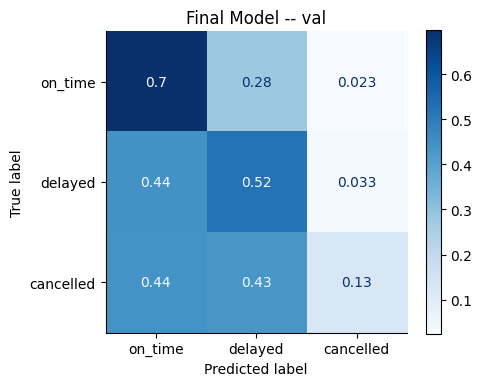

In [9]:
y_val_pred = cascade_predict(X_val_a, best_ma, model_b)
mf1_val = f1_score(y_val_true, y_val_pred, average='macro')
print(f'val cascade macro F1: {mf1_val:.4f}')
print(classification_report(y_val_true, y_val_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_val_norm = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
fig_val, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_val_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Final Model -- val')
plt.tight_layout()
plt.show()

## Test Set Results

test cascade macro F1: 0.4279
              precision    recall  f1-score   support

     on_time       0.83      0.67      0.74   3091391
     delayed       0.32      0.53      0.40    863057
   cancelled       0.12      0.17      0.15    123191

    accuracy                           0.62   4077639
   macro avg       0.43      0.46      0.43   4077639
weighted avg       0.70      0.62      0.65   4077639



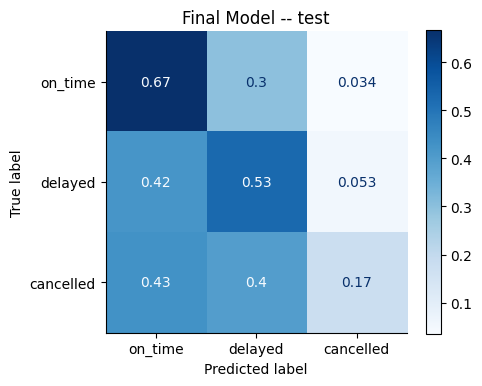

In [10]:
y_test_pred = cascade_predict(X_test_a, best_ma, model_b)
mf1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'test cascade macro F1: {mf1_test:.4f}')
print(classification_report(y_test_true, y_test_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
fig_test, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_test_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Final Model -- test')
plt.tight_layout()
plt.show()

## Full Progression v1-v8

          model  val macro F1  test macro F1
v1 flights only        0.3054         0.2954
    v2 +weather        0.3641         0.3594
    v3 +weights        0.3750         0.3770
        v4 +spw        0.2795         0.2614
v5 cascade +spw        0.3624         0.3582
      v6 +SMOTE        0.4035         0.4152
    v7 new data        0.4173         0.4329
       v8 tuned        0.4130         0.4279


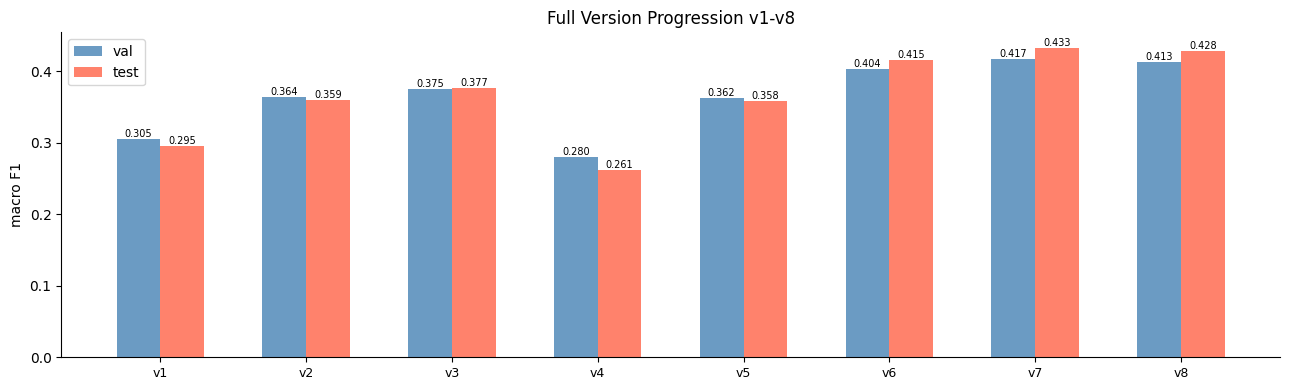

In [11]:
v1_val,  v1_test  = 0.3054, 0.2954
v2_val,  v2_test  = 0.3641, 0.3594
v3_val,  v3_test  = 0.3750, 0.3770
v4_val,  v4_test  = 0.2795, 0.2614
v5_val,  v5_test  = 0.3624, 0.3582
v6_val,  v6_test  = 0.4035, 0.4152
v7_val,  v7_test  = 0.4173, 0.4329  

comparison = pd.DataFrame({
    'model':         ['v1 flights only', 'v2 +weather', 'v3 +weights',
                      'v4 +spw', 'v5 cascade +spw', 'v6 +SMOTE',
                      'v7 new data', 'v8 tuned'],
    'val macro F1':  [v1_val, v2_val, v3_val, v4_val, v5_val, v6_val, v7_val, round(mf1_val,  4)],
    'test macro F1': [v1_test, v2_test, v3_test, v4_test, v5_test, v6_test, v7_test, round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

fig_comp, ax = plt.subplots(figsize=(13, 4))
x = np.arange(8)
width = 0.3
vals  = [v1_val, v2_val, v3_val, v4_val, v5_val, v6_val, v7_val, mf1_val]
tests = [v1_test, v2_test, v3_test, v4_test, v5_test, v6_test, v7_test, mf1_test]
ax.bar(x - width/2, vals,  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, tests, width, label='test', color='tomato',    alpha=0.8)
for i, (v, t) in enumerate(zip(vals, tests)):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=7)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(['v1','v2','v3','v4','v5','v6','v7','v8'], fontsize=9)
ax.set_ylabel('macro F1')
ax.set_title('Full Version Progression v1-v8')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

Tuning didn't help here, we went through 15 combinations and the default params from v7 still won. At this point the bottleneck is the data and the features, not the model settings.

Looking back at all 8 versions:
- v1 and v2: more features helped the overall score but cancelled recall was still basically 0
- v3 and v4: weighting helped but trying to balance three classes at once was too messy
- v5: splitting into two models was the right call, cancelled recall finally jumped
- v6: SMOTE + lowering the weight fixed the precision problem, first time we beat v3
- v7: new dataset was the biggest jump by far, the lag features made a real difference
- v8: tried to tune our way to a better score but the v7 params were already good enough

Since hyperparameter tuning didn't move the needle, we tried something simpler in the next notebook: tuning the decision thresholds on the v7 models. Raising the delay threshold from 0.5 to 0.6 pushed test F1 up to 0.4445 without any retraining at all.